# Amazon Data Analysis & Review Score Prediction

## Milestone 2 Spark Setup

In [1]:
import pyspark
from pyspark.sql import SparkSession
from pyspark import StorageLevel
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib created a temporary cache directory at /scratch/bguo3/job_47213939/matplotlib-t1mk3qn3 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Initializing our spark
"""
Formula == 
Executor instances = Total Cores - 1
Executor memory = (Total Memory - Driver Memory) / Executor Instances

Milestone 2
Executor instances = 32 − 1 = 31
Executor memory = (128 − 2) / 31 ≈ 4.06GB → 4GB per executor

Milestones 3 Update:
We had to update our Spark set-up beecause of memory leak and large overhead issues
We've run combinations of 8 cores X 8GB, 8 core X 16GB, 8 core X 24GB
This set-up depends on the resources at hand
"""


# Milestone 2 setup
# spark= (
#     SparkSession.builder
#     .appName('amazon_set')
#     .config('spark.driver.memory', '2g')
#     .config('spark.executor.instances', '31')
#     .config('spark.executor.memory', '4g')
#     .config('spark.executor.cores', '1')
#     .getOrCreate()
# )

# Milestone 3 latest set up
spark = (
    SparkSession.builder
    .appName('amazon_set')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.instances', '7')
    .config('spark.executor.memory', '24g')
    .config('spark.executor.cores', '1')
    .getOrCreate()
)

In [3]:
import requests
import pandas as pd # RECALL we're going to use spark not pandas

# Get the active Spark Context and URL
sc = spark.sparkContext
url = f"{sc.uiWebUrl}/api/v1/applications/{sc.applicationId}/executors"

# Fetch the executor data from the API
response = requests.get(url)
executors = response.json()

# Format into a readable DataFrame
df = pd.DataFrame(executors)[['id', 'totalCores', 'maxMemory', 'activeTasks', 'isActive']]
df['maxMemory_GB'] = (df['maxMemory'] / (1024**3)).round(2)
df

,id,totalCores,maxMemory,activeTasks,isActive,maxMemory_GB
0,driver,8,2388236697,0,True,2.22


### Helper Functions

In [4]:
def row_memory_count(df):
    """
    Estimate row count and memory footprint of a Spark DataFrame.

    Args:
        df: Spark DataFrame to analyze

    Prints:
        - Total number of rows in the DataFrame
        - Estimated total memory usage in GB
    """

    # How many df rows do we have?
    row_counts = df.count()
    print(f"Total row counts: {row_counts} rows")
    
    # How much does df occupy in memory?
    sample_fraction = 0.001
    sample_size_in_bytes = (
        df
        .sample(fraction=sample_fraction)
        .toPandas()
        .memory_usage(deep=True)
        .sum()
    ) 
    total_size_in_gb = sample_size_in_bytes / (sample_fraction * (1024**3))
    print(f"Total estimated size: {total_size_in_gb:.2f} GB")

def plot_bar_chart(df, groupby_col, x_label, title, has_hue=True):
    """
    Plot a horizontal bar chart of the top N categories for a Spark DataFrame column.

    Args:
        df: Spark DataFrame
        groupby_col: Column name (string) to group by
        x_label: Label for the x-axis
        title: Plot title

    Notes:
        - Counts are annotated in millions (M) by default
    """
    
    # --- Data ---
    dist_pd = (
        df
        # Groupby + Agg(count) + Sort
        .groupBy(groupby_col)
        .count()
        .orderBy(F.desc('count'))
        .toPandas()
        .loc[lambda temp_df: temp_df[groupby_col].notna(), :]
        .assign(**{
            groupby_col: lambda df: df[groupby_col].astype('category')
        })
        .sort_values(by='count', ascending=False)
    )
    
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.barplot(
        data=dist_pd,
        x='count',
        y=groupby_col,
        hue=groupby_col if has_hue else None,
        legend=False,
        palette='Blues_r' if has_hue else None,
        edgecolor='white',
        ax=ax,
        order=dist_pd[groupby_col].tolist(),
        hue_order=dist_pd[groupby_col].tolist()
    )
    # Edit text on categories
    for bar in ax.patches:
        w = bar.get_width()
        ax.text(
            w + 50_000, bar.get_y() + bar.get_height() / 2,
            f'{w/1_000_000:.2f}M',
            va='center', ha='left', fontsize=9, color='#333'
        )
    # Annotation
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold', 
        pad=15
    )
    plt.show()

def plot_histogram(df, column, x_label, title, bins=50, kde=False):
    """
    Plot a histogram for a numerical column from a Spark DataFrame.

    Args:
        df: Spark DataFrame
        column: column name (string)
        bins: number of bins
        x_label: label for x-axis
        title: plot title
    """
    
    # --- Data ---
    dist_pd = (
        df
        .select(column)
        # Use 1% sample
        .sample(fraction=0.01, seed=42)
        .toPandas()
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.histplot(
        dist_pd[column], 
        bins=bins, 
        kde=kde, 
        color='skyblue', 
        edgecolor='white', 
        ax=ax
    )
    ax.set_xlabel(
        column, 
        fontsize=11
    )
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold'
    )
    plt.show()

def plot_boxplot(df, column, x_label, title):
    """
    Plot a box plot for a numerical column from a Spark DataFrame.

    Args:
        df: Spark DataFrame
        column: column name (string) to plot
        x_label: label for the x-axis (optional)
        title: plot title (optional)
        sample_fraction: fraction of rows to sample (default 0.01 = 1%)
    """
    
    # --- Data ---
    dist_pd = (
        df
        .select(column)
        # Use 1% sample
        .sample(fraction=0.01, seed=42)
        .toPandas()
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        y=dist_pd[column], 
        color='lightblue', 
        ax=ax
    )
    ax.set_ylabel(
        x_label, 
        fontsize=11
    )
    ax.set_title(
        title, 
        fontsize=14, 
        fontweight='bold'
    )
    plt.show()

## Milestone 2 Data Collection

In [5]:
import kagglehub
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType,
    DateType
)

# Download dataset (cached by kagglehub)
base_dir = kagglehub.dataset_download('cynthiarempel/amazon-us-customer-reviews-dataset')
print('Downloaded to:', base_dir)

# Schema (recommended)
schema = StructType([
    StructField('marketplace', StringType(), True),
    StructField('customer_id', StringType(), True),
    StructField('review_id', StringType(), True),
    StructField('product_id', StringType(), True),
    StructField('product_parent', StringType(), True),
    StructField('product_title', StringType(), True),
    StructField('product_category', StringType(), True),
    StructField('star_rating', IntegerType(), True),
    StructField('helpful_votes', IntegerType(), True),
    StructField('total_votes', IntegerType(), True),
    StructField('vine', StringType(), True),
    StructField('verified_purchase', StringType(), True),
    StructField('review_headline', StringType(), True),
    StructField('review_body', StringType(), True),
    StructField('review_date', DateType(), True),
])

pattern = f'file:{base_dir}/amazon_reviews_us_*_v*.tsv'

reviews_df = (
    spark.read
        .option('header', 'true')
        .option('sep', '\t')
        .schema(schema)
        .csv(pattern)
        .withColumn('source_file', F.input_file_name())
        .withColumn('category', F.regexp_extract('source_file', r'amazon_reviews_us_([^/]+?)_v', 1))
        .filter(F.col('category') != 'multilingual')
        .drop('source_file')
)

Downloaded to: /home/bguo3/.cache/kagglehub/datasets/cynthiarempel/amazon-us-customer-reviews-dataset/versions/9


In [6]:
# Check the Spark details
print('master:', spark.sparkContext.master)
print('partitions:', reviews_df.rdd.getNumPartitions())

master: local[*]
partitions: 384


In [7]:
# from pyspark import StorageLevel
# reviews_df = reviews_df.persist(StorageLevel.MEMORY_AND_DISK)

**Observations**: 
- We decided not cache the whole df yet because with 40GB and limited temporary storage, we had an error crash on Expanse.
- When caching the SparkSQL Dataframe, doing some tasks that involve occupying some space in memory evicted the cached memory and we had memory spills in storage. Unfortunately the temp storage also spills and crashes the jupyter kernel.
- Using SLURM, we maybe able to allocate more than 1 node, so hopefully that might helps, or caching the whole df might not even be a good idea from the start.

MILESTONE 3 NOTE:
We have to update our SDSC set-up

## Milestone 2 Exploratory Data Analysis

### Overall Inspection

In [8]:
# We want to check if the df is successfully loaded

reviews_df.select('category', 'star_rating', 'product_id').show(10, truncate=False)

+--------+-----------+----------+
|category|star_rating|product_id|
+--------+-----------+----------+
|Apparel |4          |B01KL6O72Y|
|Apparel |5          |B01ID3ZS5W|
|Apparel |5          |B01I497BGY|
|Apparel |5          |B01HDXFZK6|
|Apparel |5          |B01G6MBEBY|
|Apparel |5          |B01FWRXN0Y|
|Apparel |5          |B01EXNH1HE|
|Apparel |4          |B01E7OL09O|
|Apparel |5          |B01DXHX81O|
|Apparel |3          |B01DDULIJK|
+--------+-----------+----------+
only showing top 10 rows



In [9]:
# Let's... see how big this data is!
# Row and memory count
row_memory_count(reviews_df)

Total row counts: 102899354 rows
Total estimated size: 117.13 GB


In [10]:
# Check the schema
reviews_df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- category: string (nullable = false)



| Column | Description |
|---|---|
| **marketplace** | Country/region the review was posted on (e.g. US, UK) |
| **product_id** | Unique identifier for the product (ASIN on Amazon) |
| **product_parent** | Groups product variants (e.g. same book in hardcover/paperback) under one parent ID |
| **product_title** | Name/title of the product |
| **product_category** | Category the product belongs to (e.g. Wireless, Sports, Beauty) |
| **customer_id** | Unique identifier for the reviewer |
| **review_id** | Unique identifier for the review itself |
| **star_rating** | Rating given by the customer (1–5 stars) |
| **review_headline** | Short title/summary of the review |
| **review_body** | Full text of the review |
| **review_date** | Date the review was posted |
| **helpful_votes** | Number of people who found the review helpful |
| **total_votes** | Total number of people who voted on the review (helpful or not) |
| **vine** | Whether the reviewer is part of Amazon's Vine program (`Y`/`N`) |
| **verified_purchase** | Whether the reviewer actually bought the product on Amazon (`Y`/`N`) |
| **category** | Broader/redundant category label, possibly added during data processing |


In [11]:
# Check the summary statistics
reviews_df.describe().show()

+-------+-----------+--------------------+--------------+--------------------+-------------------+--------------------+--------------------+-----------------+------------------+-----------------+---------+-----------------+--------------------+--------------------+---------+
|summary|marketplace|         customer_id|     review_id|          product_id|     product_parent|       product_title|    product_category|      star_rating|     helpful_votes|      total_votes|     vine|verified_purchase|     review_headline|         review_body| category|
+-------+-----------+--------------------+--------------+--------------------+-------------------+--------------------+--------------------+-----------------+------------------+-----------------+---------+-----------------+--------------------+--------------------+---------+
|  count|  102899354|           102899354|     102899354|           102899354|          102899354|           102899354|           102897602|        102897561|         10289

| summary | marketplace | customer_id       | review_id        | product_id     | product_parent      | product_title            | product_category | star_rating   | helpful_votes | total_votes | vine  | verified_purchase | review_headline           | review_body              | review_date   | category |
|---------|------------|-----------------|-----------------|---------------|------------------|-----------------------|----------------|---------------|---------------|-------------|-------|-----------------|-------------------------|-------------------------|---------------|---------|
| count   | 102,899,354 | 102,899,354     | 102,899,354     | 102,899,354   | 102,899,354      | 102,899,354           | 102,897,602    | 102,897,561   | 102,897,561   | 102,897,561 | 102,897,561 | 102,897,561 | 102,897,322           | 102,887,488           | 102,891,724   | 102,899,354 |
| mean    | None       | 28,337,279.36    | None            | 1,425,824,476 | 500,333,796.44   | NaN                   | None           | 4.16          | 1.90          | 2.54        | None  | None            | NaN                     | Infinity                | None          | None    |
| stddev  | None       | 15,723,537       | None            | 1,936,226,418 | 288,790,891.53   | NaN                   | None           | 1.29          | 20.77         | 22.45       | None  | None            | NaN                     | NaN                     | None          | None    |
| min     | US         | 100,000          | R100007TERQ36I  | 0000000078    | 100,000,041      | Fine in Time           | 2002-08-07     | 1             | 0             | 0           | N     | N               | All was good :)          | I mad...                | 1995-06-24    | Apparel |
| max     | US         | 9,999,996        | RZZZZYOFYZ829   | BT00IU6O8K    | 999,999,945      | 🌴 Vacation On The Beach | "Red Spring Blossom Flowers with Yellow Bees..." | 5             | 47,524        | 48,362      | Y     | Y               | 🤹🏽‍♂️🎤Great product...  | 🛅🚑🚚🚏🚙🚈🚘🚈🚘🚏🚘🚙🚎🚎... | 2015-08-31    | Wireless |

### Missingness

In [12]:
# Check missing values per columns

(
    reviews_df
    # Project all columns
    .select([
        # Count all filtered values
        F.count(
            # When it meets these conditions
            F.when(
                # Define the condition
                F.col(c).isNotNull() | (F.col(c) != ""), 
                # Define the value to return
                c
            )
        )
        # Rename to 'c'
        .alias(c)
        # Iterate all columns
        for c in reviews_df.columns
    ])
    .show()
)

+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+---------------+-----------+-----------+---------+
|marketplace|customer_id|review_id|product_id|product_parent|product_title|product_category|star_rating|helpful_votes|total_votes|     vine|verified_purchase|review_headline|review_body|review_date| category|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+---------------+-----------+-----------+---------+
|  102899354|  102899354|102899354| 102899354|     102899354|    102899354|       102897602|  102897561|    102897561|  102897561|102897561|        102897561|      102897322|  102887488|  102891724|102899354|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+---------+-----------------+------

**Columns with Missing Values**
| Column            | Missing Count | Total Rows  | Missing % |
| ----------------- | ------------- | ----------- | --------- |
| product_category  | 1,752         | 102,899,354 | 0.0017%   |
| star_rating       | 1,793         | 102,899,354 | 0.0017%   |
| helpful_votes     | 1,793         | 102,899,354 | 0.0017%   |
| total_votes       | 1,793         | 102,899,354 | 0.0017%   |
| vine              | 1,793         | 102,899,354 | 0.0017%   |
| verified_purchase | 1,793         | 102,899,354 | 0.0017%   |
| review_headline   | 11,866        | 102,899,354 | 0.0115%   |
| review_date       | 7,630         | 102,899,354 | 0.0074%   |

**Observations**: 

Missing Data is below 0.02% across all features. Given the extremely large sample size (~10^8), listwise deletion for the target and simple deterministic imputation for predictors will not affect distributional properties or predictive performance. Therefore, complex probabilistic imputation is not necessary. We decided to perform list-wise deletion and simple deterministic imputation (per requirement) to deal with missing data.

### Feature Distribution

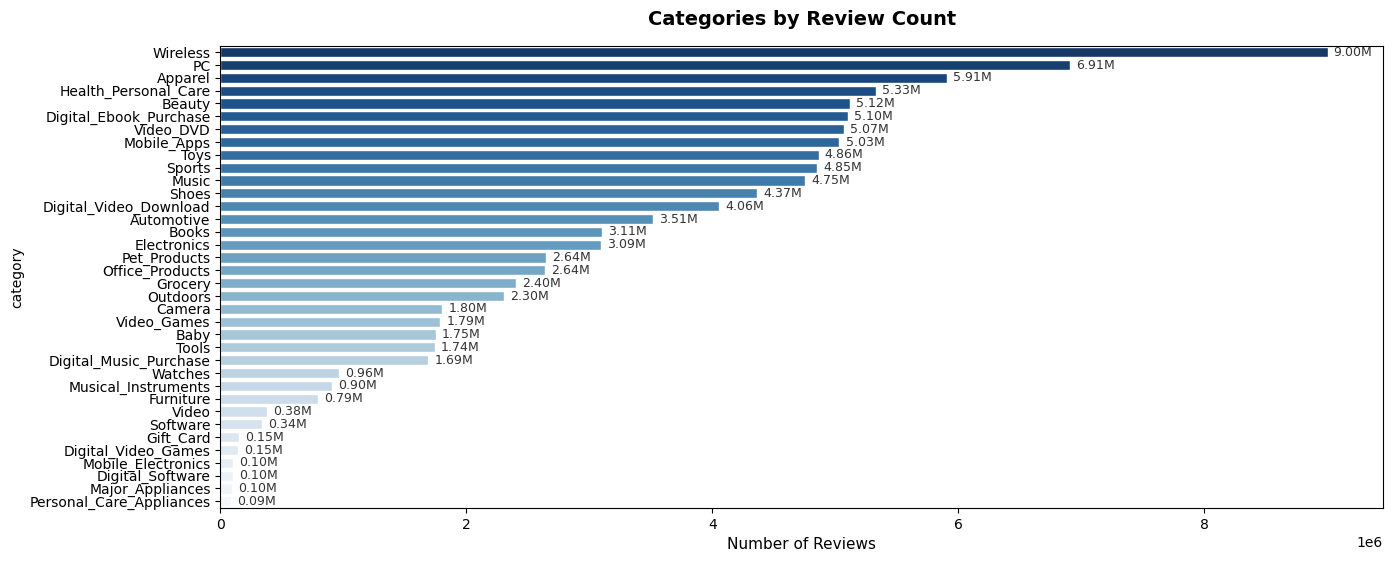

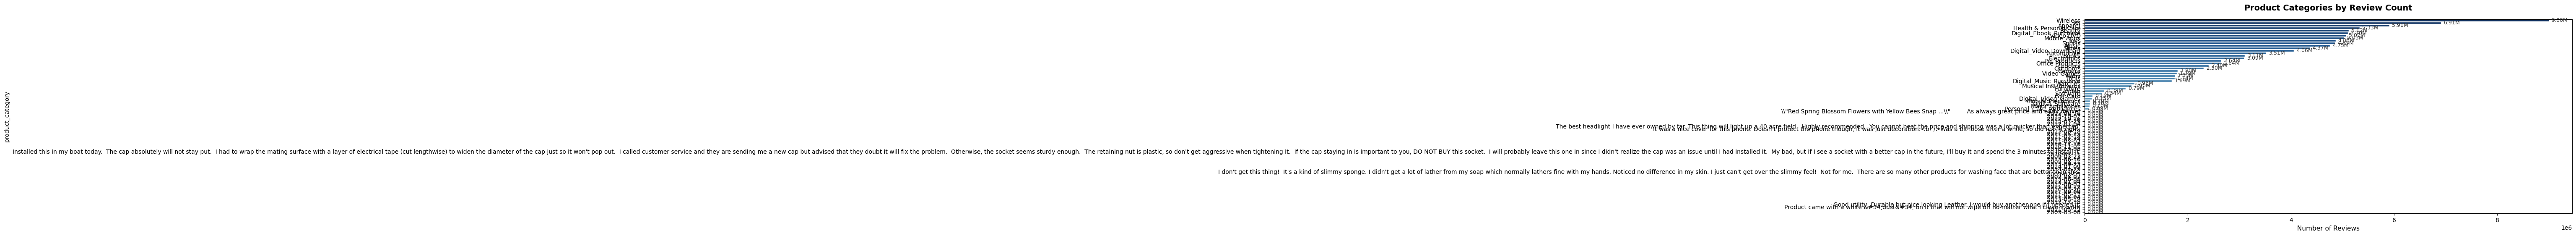

+----------------------+------------+
|product_category      |review_count|
+----------------------+------------+
|Wireless              |9001881     |
|PC                    |6908551     |
|Apparel               |5906322     |
|Health & Personal Care|5331215     |
|Beauty                |5115452     |
|Digital_Ebook_Purchase|5101676     |
|Video DVD             |5069136     |
|Mobile_Apps           |5033376     |
|Toys                  |4864243     |
|Sports                |4849563     |
+----------------------+------------+



In [13]:
# Product category distribution

plot_bar_chart(
    reviews_df, 
    'category', 
    'Number of Reviews',
    'Categories by Review Count'
)

plot_bar_chart(
    reviews_df, 
    'product_category', 
    'Number of Reviews',
    'Product Categories by Review Count'
)


# Let's play with the data. What are our most popular products?
top_categories = (
    reviews_df
    .groupBy('product_category')
    .agg(F.count('*').alias('review_count'))
    .orderBy(F.desc('review_count'))
    .limit(10)
)
top_categories.show(truncate=False)

**Observations**: 

Categories are highly unbalanced: there are a lot of technology/electronic-related categories.
That said they both have the highest and lowest count. 
This is an issue if our Machine Learning target was category classification.

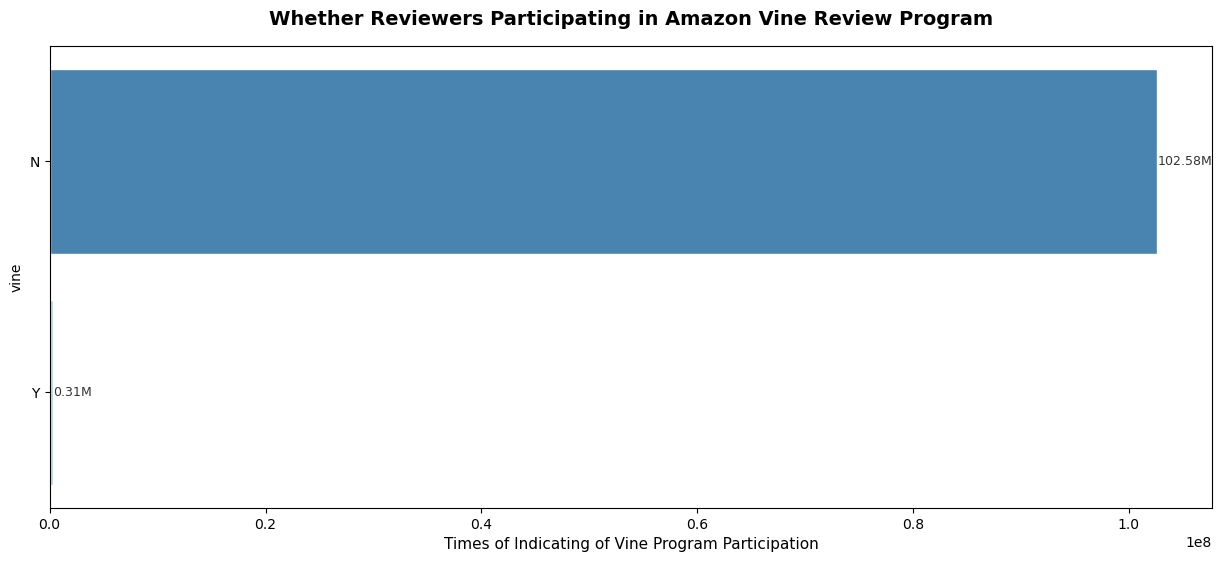

In [14]:
# Vine Distribution

plot_bar_chart(
    reviews_df, 
    'vine', 
    'Times of Indicating of Vine Program Participation', 
    'Whether Reviewers Participating in Amazon Vine Review Program'
)

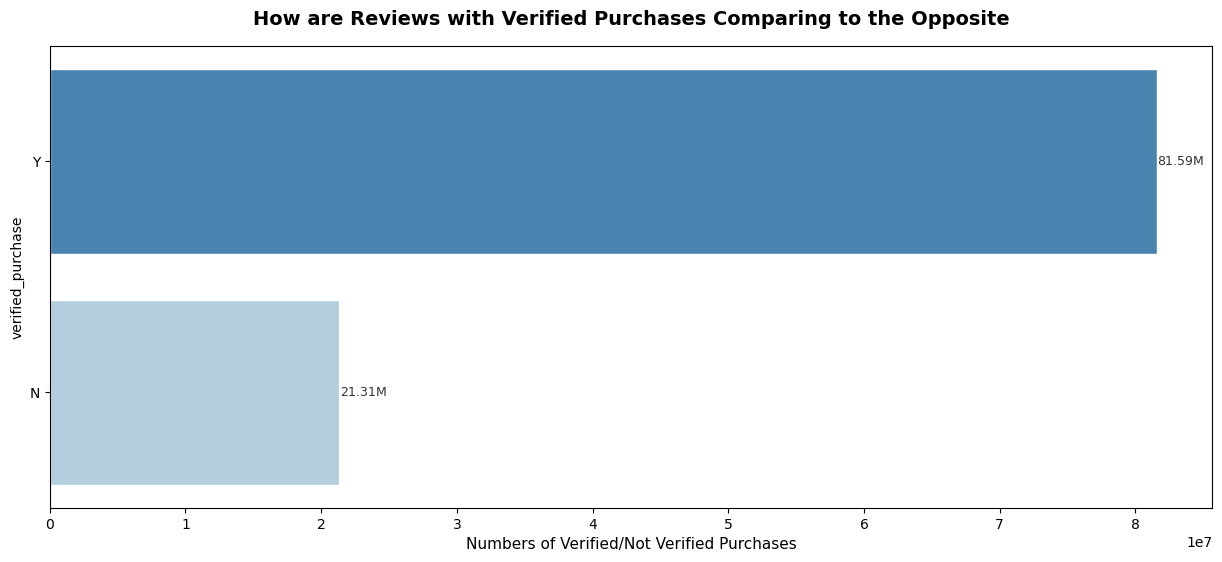

In [15]:
# Verified Purchase Distribution

plot_bar_chart(
    reviews_df, 
    'verified_purchase', 
    'Numbers of Verified/Not Verified Purchases', 
    'How are Reviews with Verified Purchases Comparing to the Opposite'
)

**Observations**:

The class for Vine is extremely imbalanced, and verified_purchases it's better but 'Y' has 60% more data than 'N'

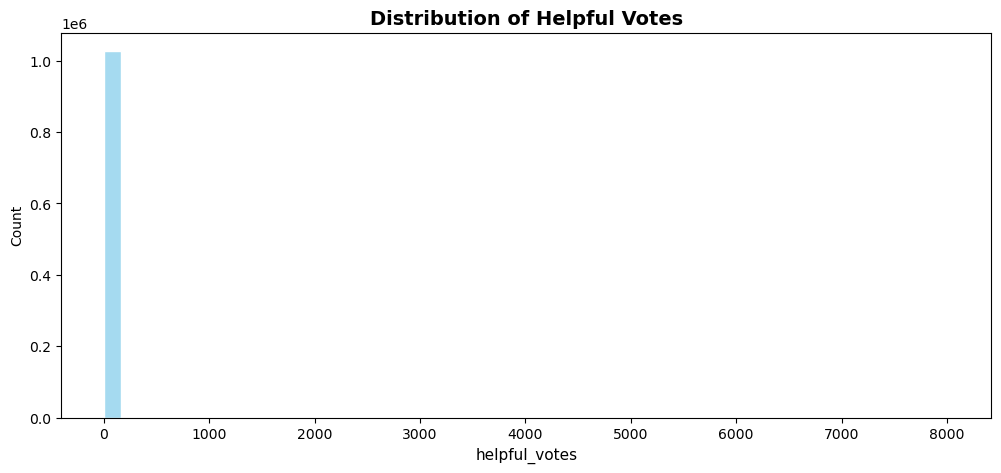

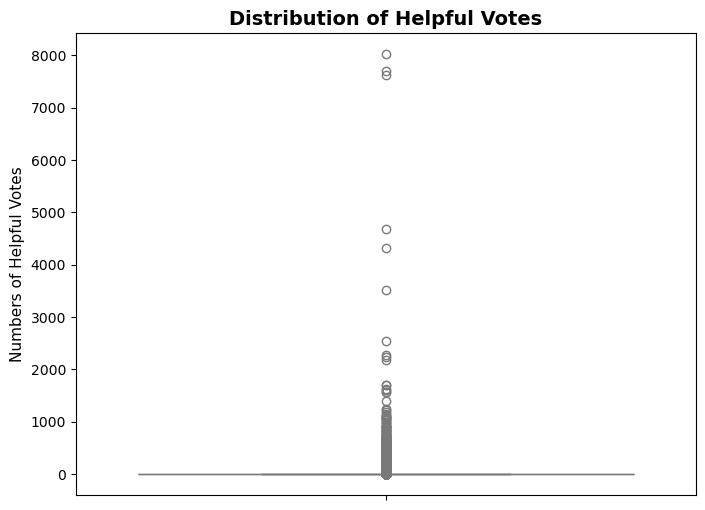

In [16]:
# Helpful Votes Distribution

plot_histogram(
    reviews_df, 
    'helpful_votes', 
    'Numbers of Helpful Votes', 
    'Distribution of Helpful Votes'
)

plot_boxplot(
    reviews_df, 
    'helpful_votes', 
    'Numbers of Helpful Votes', 
    'Distribution of Helpful Votes'
)

**Observations**:

Helpful votes is higher desnity closer to 0, while having extereme outlier value such at 8000. It would be interesting to check the review with outlier value amount that are more than 2000. So this column has extreme skewed distribution to lower values or none at all.

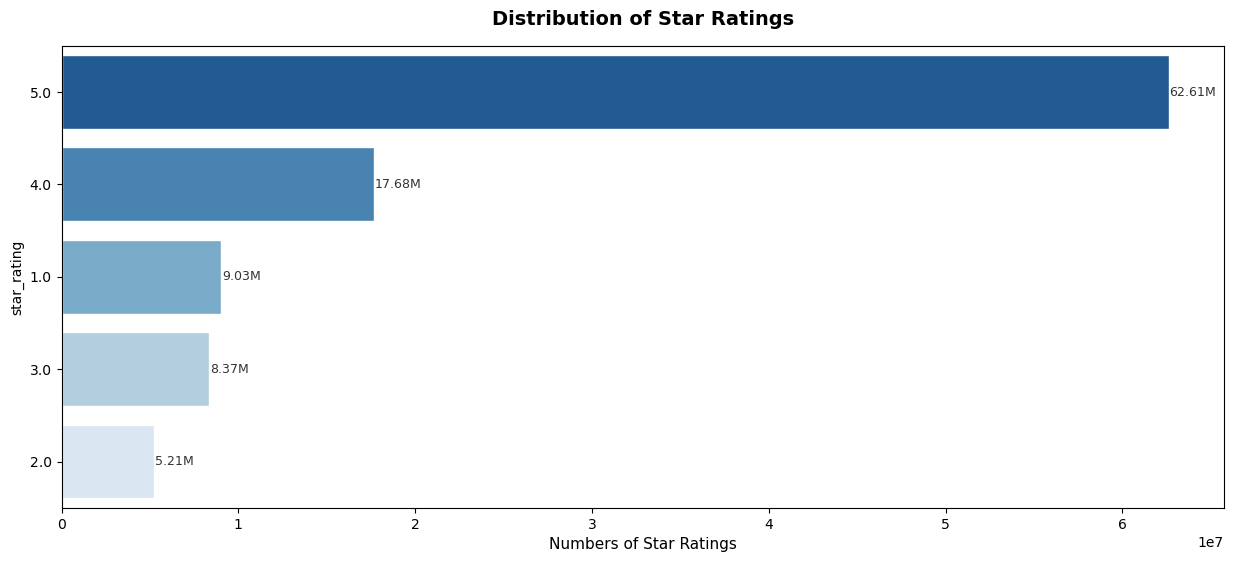

In [17]:
# Rating Distribution

plot_bar_chart(
    reviews_df, 
    'star_rating', 
    'Numbers of Star Ratings', 
    'Distribution of Star Ratings'
)

### Sport Analysis

In [18]:
# Let's focus on a sports-specific data frame for plotting 
# since sports have the lowest review counts among the most popular categories

# We'll scale this up for our own needs with all the data in the future
sports_df = (
    reviews_df
    .filter(F.lower(F.col('product_category')) == 'sports')
)

# materialize cache (important)
sports_df.cache()

# Row and memory counts for sports_df
row_memory_count(sports_df)

Total row counts: 4849563 rows
Total estimated size: 5.11 GB


**Observations**: 

- We can see that sports_df occupied about 5 GB of data, which is why setting the memory of 4GB per executor does not work
- We already know that the review_df has (total row: 102899354, total size: 118.75 GB), since sports_df row counts is around 4% of the review_df row counts, so it's reasonable to directly estimate that sports_df memory is around 4% of review_df's.

In [19]:
# How about if we check for the unique sports products by product_id

distinct_sports_products = (
    sports_df
    .select('product_id')
    .distinct()
    .count()
)
print(f'Distinct Sports products: {distinct_sports_products}')

Distinct Sports products: 1046129


+----------+-----+
|product_id|count|
+----------+-----+
|B001HBHNHE|7405 |
|7245456313|3693 |
|B00FX0S4DC|3051 |
|B000UVVX28|3006 |
|B002QZ1RS6|2922 |
|B003TJH3LI|2823 |
|B005M1P85O|2786 |
|B001EJMS6K|2560 |
|B00178CS4K|2299 |
|B00B1N0R6C|2278 |
+----------+-----+



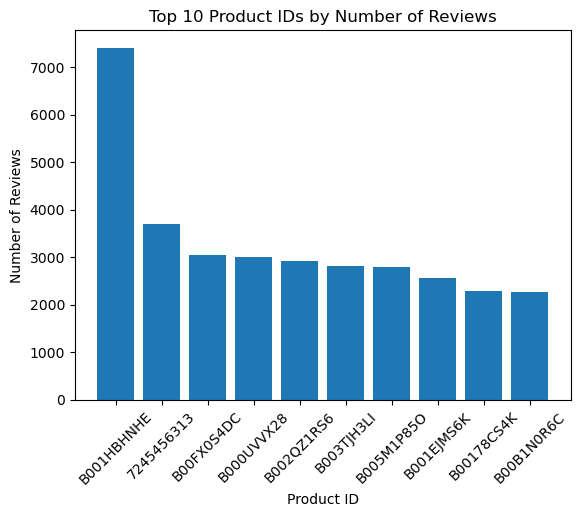

In [20]:
# --- Data ---
top10_products = (
    sports_df
    .groupBy('product_id')
    .count()
    .orderBy(F.desc('count'))
    .limit(10)
)
top10_products.show(truncate=False)
top10_pd = top10_products.toPandas()

# --- Plot ----
plt.figure()
plt.bar(top10_pd['product_id'], top10_pd['count'])
plt.xticks(rotation = 45)
plt.xlabel('Product ID')
plt.ylabel('Number of Reviews')
plt.title('Top 10 Product IDs by Number of Reviews')
plt.show()

**Observation**:

The result shows that many products receive at least one review, so unique product count < total row count

In [21]:
# Discretize star rating 
# (As it was defined to be an integer, this just ensures it works as expected)

sports_df_clean = (
    sports_df
    .withColumn("star_rating_int", F.expr("try_cast(star_rating as int)"))
    .filter(F.col("star_rating_int").isNotNull())
)

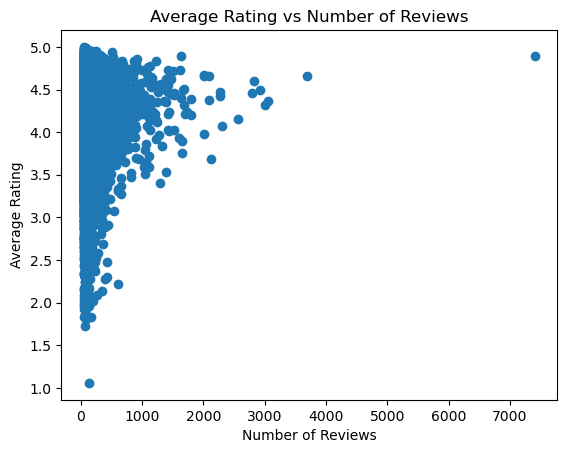

In [22]:
# We want to see if number of review correlates with average ratings

# --- Data ---
average_rating_df = (
    sports_df_clean  
    .groupBy("product_id")
    .agg(
        F.avg("star_rating_int").alias("avg_rating"),
        F.count("*").alias("num_reviews")
    )
     # avoid tiny sample noise
    .filter(F.col("num_reviews") > 50) 
)
average_rating_pd = average_rating_df.toPandas()

# --- Plot ---
plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xlabel('Number of Reviews')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

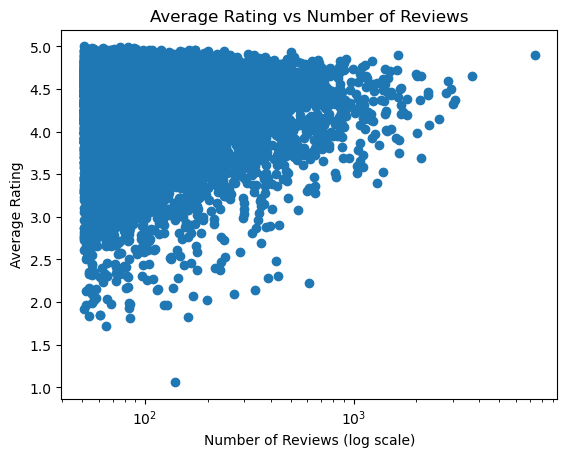

In [23]:
# We want to see it in log plot

plt.figure()
plt.scatter(average_rating_pd['num_reviews'], average_rating_pd['avg_rating'])
plt.xscale('log')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Average Rating')
plt.title('Average Rating vs Number of Reviews')
plt.show()

## Milestone 3 Data Preprocessing 

In [8]:
import time
start = time.time()

## MORE PLAN

# HashDF with IDF, NO Word2Vec, semantic relationship, it;s super slow and has MANT Columns

# Sentiment Score

# Text pReprocessing

# Text EDA

# A lot of things from here:
# https://www.kaggle.com/code/asadozzaman/text-data-preprocessing-sentiment-analysis#Step-1:Importing-Libraries

### Import Modules

In [9]:
from functools import reduce
from pyspark.ml import Transformer, Pipeline
from pyspark.ml.param.shared import Param, Params
from pyspark.ml.feature import (
    StringIndexer, VectorAssembler, 
    StandardScaler, SQLTransformer
)
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import seaborn as sns

### Subsample Dataframe for Testing (Row Sampling)

In [10]:
# Only use for subsampling
preprocess_df = (
    reviews_df
    .sample(
        withReplacement=False, 
        fraction=0.01
    )
)

# Only use for production
# preprocess_df = reviews_df

### Relevant Features for ML (Feature Selection)

| Column            | Status | Justification / Impact                                                                                              |
| ----------------- | ------ | ------------------------------------------------------------------------------------------------------------------- |
| marketplace       | ✅ / ❌    | Restrict to U.S. marketplace for English-language consistency; won’t add predictive value after filtering           |
| customer_id       | ✅ / ❌      | Could allow aggregation of user behavior but not essential |
| review_id         | ❌      | Unique key only; no predictive value                                                                                |
| product_id        | ✅ / ❌      | Enables aggregation to detect product-specific rating tendencies, could allow aggregation of product behavior but not essential                    |
| product_parent    | ❌    | We can just rely on product_id                      |
| product_title     | ✅      | Useful for sanity-checking product_id; can be tokenized for NLP features if needed, not needed now                                |
| category  | ✅      | rating could be different based on categories, and different categories may have varying rating distributions                       |
| product_category  | ❌      |  This is a redundant features that overlaps with category and contains some random values as categories such as review and datetime type                           |
| star_rating       | ✅✅✅   | Target variable; ranking matters but intervals may not be perfectly aligned                                         |
| helpful_votes     | ✅ / ❌    | Indicates perceived usefulness; can combine with total_votes to create helpfulness ratio, after that, we don't need it anymore                            |
| total_votes       | ✅      | Indicates overall engagement; can combine with helpful_votes to measure helpfulness ratio                           |
| vine              | ❌    | Binary; Amazon Vine reviews may indicate incentivized reviews, extreme class imbalance issues                                       |
| verified_purchase | ✅      | Affects credibility; verified reviews may correlate with stronger sentiment, obvious class imbalance                                         |
| review_headline   | ✅      | Useful for NLP; headlines often contain strong sentiment signals                                                 |                                                |
| review_body       | ✅      | Primary feature for NLP: tokenization, sentiment analysis, review length, vocabulary frequency                      |
| review_date       | ❌      | Despite enabling seasonality/trend analysis; can be transformed into month, year, or holiday-period indicators, we will need time-awared version of train/test split, which is not available in Spark MLlib            |


In [11]:
# Discard features with strictly ❌ sign

preprocess_df = (
    preprocess_df
    # Discard irrelevant features
    .select([
        feat 
        for feat in reviews_df.columns 
        if feat not in [
        'customer_id',
        'product_id',
        'product_title',
        'review_id',
        'product_parent',
        'product_category',
        'vine',
        'review_date'
        ]
    ])
    # Discard feature 'marketplace' after filtering
    .filter(F.col('marketplace') == 'US')
    .drop('marketplace')
    .withColumn("star_rating", F.col("star_rating").cast("double"))
)

### Handle Missing Values (Row Filtering & Value Imputation)

In [12]:
# Remove the missing rows for star rating columns
# We don't want to impute any artificial values 

# Perform list-wise deletion
preprocess_df = preprocess_df.filter(
    reduce(
        # Define action
        lambda x, y: 
        x & y,
        # Define a condition 
        [F.col('star_rating').isNotNull() | (F.col('star_rating') != "")]
     )
)

In [13]:
# Impute the missing rows for features with specific value 
# I did not use pyspark.ml.feature.Imputer and use pyspark.sql.DataFrame.fillna instead
# Because I need fill out non-numeric features and in this case, constant imputation is better than statistical imputation while efficient

preprocess_df = preprocess_df.fillna({
    'category': 'Unknown',
    "verified_purchase": "Unknown",
    "review_headline": "",
    "review_body": "",
    'helpful_votes': 0,
    'total_votes': 0
})

In [14]:
# Check for missing values (uncomment)
(
    preprocess_df
    # Project all columns
    .select([
        # Count all filtered values
        F.count(
            # When it meets these conditions
            F.when( F.col(c).isNull(), c)
        )
        # Rename to 'c'
        .alias(c)
        # Iterate all columns
        for c in preprocess_df.columns
    ])
    .show()
)

+-----------+-------------+-----------+-----------------+---------------+-----------+--------+
|star_rating|helpful_votes|total_votes|verified_purchase|review_headline|review_body|category|
+-----------+-------------+-----------+-----------------+---------------+-----------+--------+
|          0|            0|          0|                0|              0|          0|       0|
+-----------+-------------+-----------+-----------------+---------------+-----------+--------+



### Create New Features (Feature Engineering)

In [15]:
# Helpful Ratio = Helpful Vote / Total Vote --> Relative Useful

preprocess_df = (
    preprocess_df
    .withColumns({
        "helpful_ratio": F.when(
            F.col("total_votes") > 0,
            F.col("helpful_votes") / F.col("total_votes")
        ).otherwise(0),

        "review_len": F.length("review_body"),
        "review_word_counts": F.size(F.split(F.col("review_body"), " ")),

        "review_headline_len": F.length("review_headline"),
        "review_headline_word_counts": F.size(F.split(F.col("review_headline"), " "))
    })
    .drop('helpful_votes')
)

preprocess_df.select(['helpful_ratio','review_len', 'review_word_counts', 'review_headline_len', 'review_headline_word_counts']).show()

+------------------+----------+------------------+-------------------+---------------------------+
|     helpful_ratio|review_len|review_word_counts|review_headline_len|review_headline_word_counts|
+------------------+----------+------------------+-------------------+---------------------------+
|0.8571428571428571|       366|                71|                 17|                          2|
|               0.0|       169|                37|                 45|                         11|
|               0.0|       393|                76|                 56|                         13|
|               0.0|         4|                 1|                 10|                          2|
|               0.0|        85|                18|                 30|                          8|
|               0.0|        91|                19|                 10|                          2|
|               0.0|       730|               144|                 48|                          9|
|         

### Split Train/Test/Validation Sets (Row Sampling)

In [16]:
# Caching
preprocess_df = preprocess_df.persist(StorageLevel.MEMORY_AND_DISK)

train_df, val_df, test_df = preprocess_df.randomSplit(
    [0.7, 0.15, 0.15], 
    seed=42
)
# Caching
train_df = train_df.persist(StorageLevel.MEMORY_AND_DISK)

for df in [train_df, val_df, test_df]:
    row_memory_count(df)

Total row counts: 720439 rows
Total estimated size: 0.44 GB
Total row counts: 154494 rows
Total estimated size: 0.11 GB
Total row counts: 154359 rows
Total estimated size: 0.08 GB


### Encode Category Features (Feature Encoding)

In [17]:
# Define categorical encoding (string indexer) step 
indexer1 = StringIndexer(
    inputCol='verified_purchase',
    outputCol='verified_purchase_idx',
    handleInvalid='keep'
)

indexer2 = StringIndexer(
    inputCol="category",
    outputCol="category_idx",
    handleInvalid="keep"
)

**Observations**:

- helpful_ratio: Helpful Vote / Total Vote --> Relative Useful
- review_len & review_headline_len: Length of text should give more valuable information
- review_word_counts & review_headline_word_counts: Same reason above
- After checking their distribution through histograms, they all have long-tail right-skewed distribution

### Handle Unbalanced Classes (Feature Engineering)

In [18]:
# Gather class count
weight_total_count = train_df.count()
weight_class_counts = (
    train_df
    .groupBy('star_rating')
    .count()
    .collect()
)
# Get weights as dictionary
weights_map = {
    class_row['star_rating'] : class_row['count']/ weight_total_count
    for class_row in weight_class_counts
}

# Define the transformer class to wrap around this operation
class ClassWeightAdder(Transformer):
    def __init__(self, inputCol="star_rating", outputCol="class_weight", weights_map=None):
        super().__init__()
        self.inputCol = inputCol
        self.outputCol = outputCol
        self.weights_map = weights_map or {}

    def _transform(self, df):
        # create Spark Map literal
        weights_spark = [
            F.lit(x) 
            for kv in self.weights_map.items() 
            for x in kv
        ]
        
        return df.withColumn(
            self.outputCol,
            F.create_map(weights_spark)[F.col(self.inputCol)]
        )

# Define the class re-weighting step
class_weights_transformer = ClassWeightAdder(
    inputCol="star_rating",
    outputCol="class_weight",
    weights_map=weights_map
)

### Handle Skew Distribution (Feature Scaling)

In [19]:
# Define numeric features to be scaled
feature_cols1 = [
    "total_votes",
    "helpful_ratio",
    "review_len",
    "review_word_counts",
    "review_headline_len",
    "review_headline_word_counts"
]

## Define the assembler step
# Assemble them into arrays in form: 
# [helpful_ratio, total_votes, ..., 'review_headline_word_counts']
assembler1 = VectorAssembler(
    inputCols=feature_cols1,
    outputCol="assembled_features"
)

# Define the standard scaling step
# Scale numeric features that are skewed
scaler = StandardScaler(
    inputCol="assembled_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

### Assemble relevant & Drop irrelevant features (Feature Engineering)

In [20]:
# Define numeric features to be scaled
feature_cols2 = [
    "verified_purchase_idx",
    "category_idx",
    "scaled_features"
]

## Define the assembler step
# Assemble them into arrays in form: 
# [helpful_ratio, total_votes, ..., 'review_headline_word_counts']
assembler2 = VectorAssembler(
    inputCols=feature_cols2,
    outputCol="finalized_features"
)

# Define the drop step
col_remover = SQLTransformer(
    statement="""
    SELECT star_rating, finalized_features, class_weight
    FROM __THIS__
    """
)

### Pipeline all stages

In [21]:
# Define a pipeline using all previous steps
pipeline = (
    Pipeline(stages=[
        indexer1, 
        indexer2,
        class_weights_transformer,
        assembler1,
        scaler,
        assembler2,
        col_remover
    ])
    .fit(train_df)
)

# Fit and transform the pipeline
# Caching
train_final = pipeline.transform(train_df).persist(StorageLevel.MEMORY_AND_DISK)
val_final = pipeline.transform(val_df).persist(StorageLevel.MEMORY_AND_DISK)
test_final = pipeline.transform(test_df)

# Un-caching
preprocess_df.unpersist()
train_df.unpersist()

train_final.show(3)
val_final.show(3)
test_final.show(3)

+-----------+--------------------+------------------+
|star_rating|  finalized_features|      class_weight|
+-----------+--------------------+------------------+
|        1.0|[1.0,2.0,-0.14636...|0.0880671368429527|
|        1.0|[1.0,2.0,-0.14636...|0.0880671368429527|
|        1.0|[1.0,2.0,-0.14636...|0.0880671368429527|
+-----------+--------------------+------------------+
only showing top 3 rows

+-----------+--------------------+------------------+
|star_rating|  finalized_features|      class_weight|
+-----------+--------------------+------------------+
|        1.0|[1.0,2.0,-0.14636...|0.0880671368429527|
|        1.0|[1.0,2.0,-0.14636...|0.0880671368429527|
|        1.0|[1.0,2.0,-0.14636...|0.0880671368429527|
+-----------+--------------------+------------------+
only showing top 3 rows

+-----------+--------------------+------------------+
|star_rating|  finalized_features|      class_weight|
+-----------+--------------------+------------------+
|        1.0|[1.0,2.0,-0.14636..

In [22]:
# train_df.explain(extended=True)

# train_final.rdd.toDebugString()

In [23]:
elapsed = time.time() - start
print(f"Preprocessing took: {elapsed:.2f} seconds")

Preprocessing took: 222.31 seconds


## Milestone 3 ML Tasks

In [40]:
start = time.time()

### Baseline Model: Logistic Regression

In [41]:
# Evaluate using Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol='star_rating',
    predictionCol='prediction_lr',
    metricName='accuracy'
)

# Define model with weightCol
log_reg = LogisticRegression(
    featuresCol='finalized_features',
    labelCol='star_rating',
    predictionCol='prediction_lr',
    weightCol='class_weight',
    maxIter=20,
    regParam=0.0,
    elasticNetParam=0.0
)

# Fit and Transform
log_reg_model = log_reg.fit(train_final)
train_lr_pred = log_reg_model.transform(train_final)
val_lr_pred = log_reg_model.transform(val_final)

# Evaluate
print(f'LogReg Train Accuracy: {evaluator.evaluate(train_lr_pred):.4f}')
print(f'LogReg Validation Accuracy: {evaluator.evaluate(val_lr_pred):.4f}')

LogReg Train Accuracy: 0.6084
LogReg Validation Accuracy: 0.6069


### Improved Model: Random Forest

In [42]:
# Evaluate using Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol='star_rating',
    predictionCol='prediction_rf',
    metricName='accuracy'
)

# Define model with weightCol
rf = RandomForestClassifier(
    featuresCol='finalized_features',
    labelCol='star_rating',
    predictionCol='prediction_rf',
    numTrees=25,
    maxDepth=8,
    maxBins=37,
    # seed=42,
    weightCol='class_weight'
)

# Fit and Transform
rf_model = rf.fit(train_final)
train_rf_pred = rf_model.transform(train_final)
val_rf_pred = rf_model.transform(val_final)

# Evaluate
print(f'SET A:')
print(f'RanFor Train Accuracy: {evaluator.evaluate(train_rf_pred):.4f}')
print(f'RanFor Validation Accuracy: {evaluator.evaluate(val_rf_pred):.4f}')

SET A:
RanFor Train Accuracy: 0.6098
RanFor Validation Accuracy: 0.6083


In [43]:
elapsed = time.time() - start
print(f"ML took: {elapsed:.2f} seconds")

ML took: 67.06 seconds


In [44]:
# Try for numbers of tree > 30 and run in OOM issue

### Visualize the Graph of Fit of Models

In [25]:
start = time.time()

<Axes: >

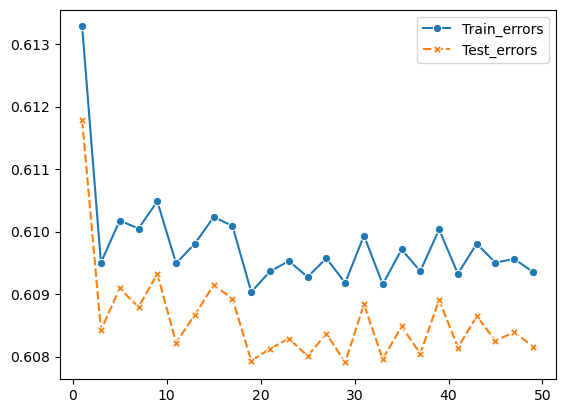

In [26]:
# Evaluate using Accuracy
evaluator = MulticlassClassificationEvaluator(
    labelCol='star_rating',
    predictionCol='prediction_rf',
    metricName='accuracy'
)

# Initialize the error array
train_errs, test_errs = [], []

# Iterate it N times
start_num = 1
end_num = 50
for i in range(start_num, end_num, 2):
    # Define model with weightCol
    rf = RandomForestClassifier(
        featuresCol='finalized_features',
        labelCol='star_rating',
        predictionCol='prediction_rf',
        numTrees=i,
        maxDepth=8,
        maxBins=37,
        # seed=42,
        weightCol='class_weight'
    )
    
    # Fit and Transform
    rf_model = rf.fit(train_final)
    train_rf_pred = rf_model.transform(train_final)
    val_rf_pred = rf_model.transform(val_final)

    # Evaluate
    train_errs.append(evaluator.evaluate(train_rf_pred))
    test_errs.append(evaluator.evaluate(val_rf_pred))

df = pd.DataFrame(
    data={
        'Train_errors': train_errs,
        'Test_errors': test_errs
    }, 
    index=range(start_num, end_num, 2)
)

sns.lineplot(df, markers=True)

In [27]:
elapsed = time.time() - start
print(f"ML Fit Graph took: {elapsed:.2f} seconds")

ML Fit Graph took: 896.91 seconds


### Let's try playing around with the hyper parameters. We're going change the trees and depths.

In [49]:
start = time.time()

In [50]:
# Define model with weightCol
rf_b = RandomForestClassifier(
    featuresCol='finalized_features',
    labelCol='star_rating',
    predictionCol='prediction_rf',
    numTrees=20,
    maxDepth=6,
    maxBins=37,
    # seed=42,
    weightCol='class_weight'
)

# Fit and Transform
rf_model_b = rf_b.fit(train_final)
train_rf_pred_b = rf_model_b.transform(train_final)
val_rf_pred_b = rf_model_b.transform(val_final)

# Evaluate
print(f'SET B:')
print(f'Ran For Train Accuracy: {evaluator.evaluate(train_rf_pred_b):.4f}')
print(f'Ran For Validation Accuracy: {evaluator.evaluate(val_rf_pred_b):.4f}')

SET B:
Ran For Train Accuracy: 0.6085
Ran For Validation Accuracy: 0.6070


In [51]:
# Define model with weightCol
rf_c = RandomForestClassifier(
    featuresCol='finalized_features',
    labelCol='star_rating',
    predictionCol='prediction_rf',
    numTrees=25,
    maxDepth=10,
    maxBins=37,
    # seed=42,
    weightCol='class_weight'
)

# Fit and Transform
rf_model_c = rf_c.fit(train_final)
train_rf_pred_c = rf_model_c.transform(train_final)
val_rf_pred_c = rf_model_c.transform(val_final)

# Evaluate
print(f'SET C:')
print(f'Ran For Train Accuracy: {evaluator.evaluate(train_rf_pred_c):.4f}')
print(f'Ran For Validation Accuracy: {evaluator.evaluate(val_rf_pred_c):.4f}')

SET C:
Ran For Train Accuracy: 0.6119
Ran For Validation Accuracy: 0.6103


In [52]:
elapsed = time.time() - start
print(f"ML Hyperparameter Tuning took: {elapsed:.2f} seconds")

ML Hyperparameter Tuning took: 136.23 seconds


**Observations**:

- This is where knowing your Spark set-up matters. We've run into heap issues exploring this data when the tree count grows.
- We believe that we're going to have work more on our features. If LR and RF are at the same level, then we're going to have to improve something
- We may re-use some combo of B or C here, but again this all becomes a heap issue.
- The distributed computing is GREAT! Seriously we're getting through Gigabytes of Data, in minutes. We ran this notebook in under 30 minutes with our Milestone 2!


We've reached out to our instructors regarding the size of our data as the training and validation are taking up a lot of overhead. We decided to stick to a smaller subset of the whole. Right now, we're running 1% well enough in terms of speed, and we want to scale up to 5%/10%.



Let's see what the plots can tell us. We're going to use the pyspark.ml.evaluation library:

### Comparison Between Models

In [56]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_eval_lr = RegressionEvaluator(
    labelCol='star_rating',
    predictionCol='prediction_lr',
    metricName='rmse'
)

rmse_eval_rf = RegressionEvaluator(
    labelCol='star_rating',
    predictionCol='prediction_rf',
    metricName='rmse'
)

# Logistic Regression
train_lr_rmse = rmse_eval_lr.evaluate(train_lr_pred)
val_lr_rmse = rmse_eval_lr.evaluate(val_lr_pred)

# Random Forest A
train_rf_a_rmse = rmse_eval_rf.evaluate(train_rf_pred)
val_rf_a_rmse = rmse_eval_rf.evaluate(val_rf_pred)

# Random Forest B
train_rf_b_rmse = rmse_eval_rf.evaluate(train_rf_pred_b)
val_rf_b_rmse = rmse_eval_rf.evaluate(val_rf_pred_b)

# Random Forest C
train_rf_c_rmse = rmse_eval_rf.evaluate(train_rf_pred_c)
val_rf_c_rmse = rmse_eval_rf.evaluate(val_rf_pred_c)

In [57]:
models = ['LogReg','RF_A','RF_B','RF_C']

train_rmse = [
    train_lr_rmse,
    train_rf_a_rmse,
    train_rf_b_rmse,
    train_rf_c_rmse
]

val_rmse = [
    val_lr_rmse,
    val_rf_a_rmse,
    val_rf_b_rmse,
    val_rf_c_rmse
]

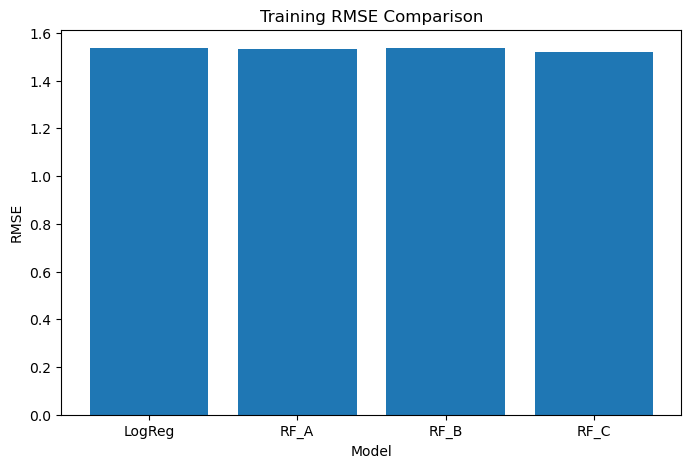

In [58]:
# training RMSE
plt.figure(figsize=(8,5))
plt.bar(models, train_rmse)

plt.title('Training RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.show()

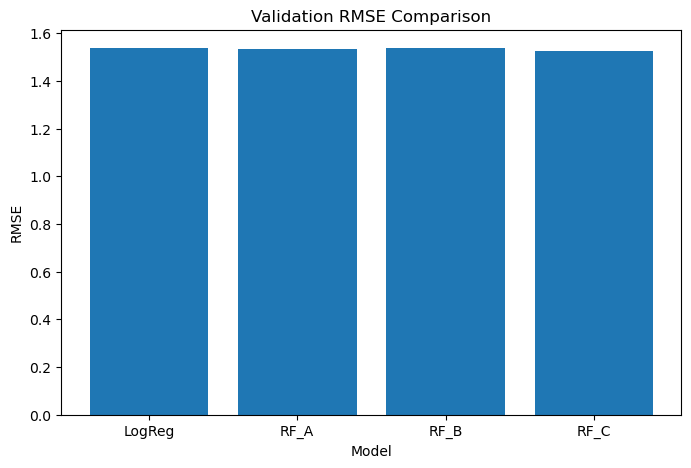

In [59]:
# validation RMSE
plt.figure(figsize=(8,5))
plt.bar(models, val_rmse)

plt.title('Validation RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.show()

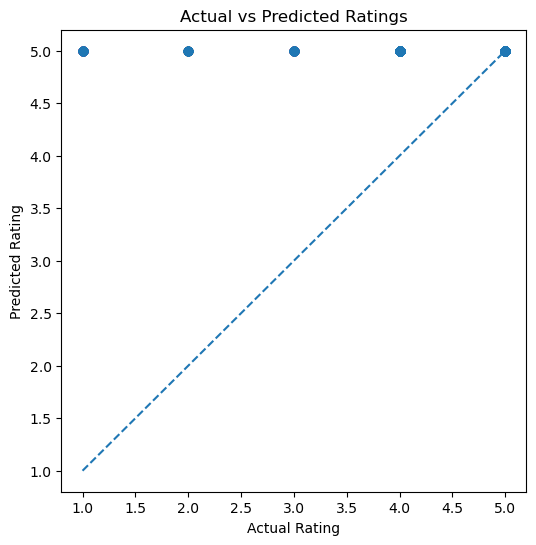

In [60]:
# Actual vs Predicted Scatter Plot
sample_df = val_rf_pred_b.select('star_rating', 'prediction_rf').sample(0.01).toPandas()

plt.figure(figsize=(6,6))
plt.scatter(sample_df['star_rating'], sample_df['prediction_rf'], alpha=0.3)

plt.plot([1,5],[1,5], linestyle='--')

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings')

plt.show()

### Feature Importance

Feature count: 8
RF importance count: 8
                       feature  importance
5           review_word_counts    0.248081
4                   review_len    0.210397
2                helpful_ratio    0.169301
6          review_headline_len    0.126052
1                 category_idx    0.122743
3                  total_votes    0.105226
7  review_headline_word_counts    0.018200
0        verified_purchase_idx    0.000000


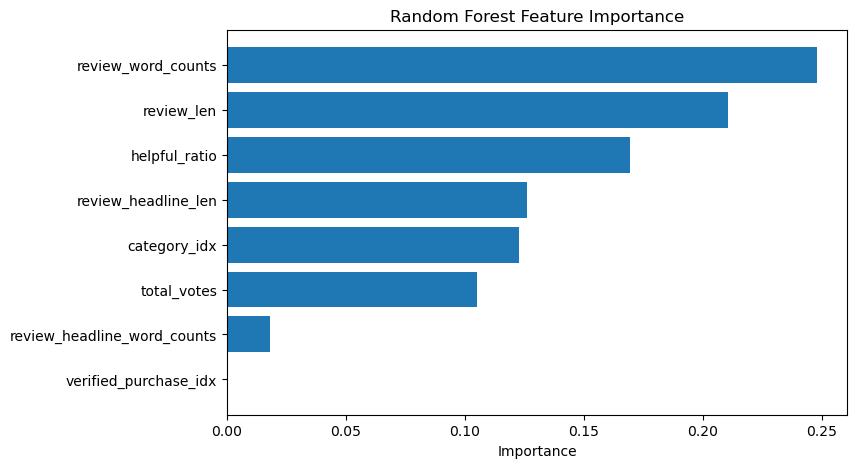

In [61]:
# Random Forest Feature Importance Plot

import matplotlib.pyplot as plt

feature_columns = [
    'verified_purchase_idx',
    'category_idx',
    'helpful_ratio',
    'total_votes',
    'review_len',
    'review_word_counts',
    'review_headline_len',
    'review_headline_word_counts'
]

importances = rf_model_b.featureImportances.toArray()

print('Feature count:', len(feature_columns))
print('RF importance count:', len(importances))

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()